In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Настройка визуализации
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

# Загрузка обработанного датасета
df = pd.read_excel('wb_products_processed.xlsx')
print("Размер данных:", df.shape)

# Информация о колонках и типах данных
df.info()

# Проверка на пропуски (для контроля)
print("\nПропущены значения в столбцах:")
missing = df.isnull().sum()
missing[missing > 0]

# Числовые колонки (обработанные)
numeric_cols = [
    'price_winsorized',
    'price_no_discount_winsorized', 
    'discount_pct_winsorized',
    'rating_winsorized',
    'reviews_count_log',
    'supplier_rating_winsorized',
    'product_value',
    'discount_score',
    'savings_percent'
]

# Определение колонок для анализа
# Категориальные колонки (закодированные и исходные)
categorical_cols = [
    'gender_encoded',      # 0-ж,1-м,2-дев,3-мал,4-дет,5-не указан
    'country_encoded',
    'price_tier',          # 'Эконом', 'Стандарт', 'Бизнес', 'Премиум'
    'is_bestseller',
    'brand_freq',
    'subject_id_freq',
    'category_query_freq',
    'color_main'
]

# Дополнительные колонки
id_cols = ['product_id', 'imt_id', 'name', 'brand', 'category_query']

# Проверка, что все колонки существуют
for col in numeric_cols + categorical_cols + id_cols:
    if col not in df.columns:
        print(f"Внимание: колонка '{col}' отсутствует в датафрейме")

Размер данных: (3708, 45)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3708 entries, 0 to 3707
Data columns (total 45 columns):
 #   Column                        Non-Null Count  Dtype         
---  ------                        --------------  -----         
 0   product_id                    3708 non-null   int64         
 1   imt_id                        3708 non-null   int64         
 2   name                          3708 non-null   object        
 3   brand                         3708 non-null   object        
 4   price                         3708 non-null   int64         
 5   price_no_discount             3708 non-null   int64         
 6   discount_pct                  3708 non-null   int64         
 7   rating                        3708 non-null   float64       
 8   reviews_count                 3708 non-null   int64         
 9   subject_id                    3708 non-null   int64         
 10  supplier_rating               3708 non-null   float64       
 11  size

Гипотезы:
H1:
Нулевая гипотеза (H0): Средний рейтинг товаров со скидкой 30–50% не выше, чем у товаров со скидкой >70%
Альтернативная (H1): Средний рейтинг в группе 30–50% выше, чем в группе >70%

H2:
Нулевая гипотеза (H0): Средний рейтинг женской одежды не отличается от мужской
Альтернативная (H1): Средний рейтинг женской одежды выше, чем мужской

H3:
Нулевая гипотеза (H0): Средняя цена не различается между странами (Россия, Китай, Италия/Франция)
Альтернативная (H1): Средняя цена различается хотя бы между двумя странами

H4:
Нулевая гипотеза (H0): Средний процент скидки премиум-брендов не ниже, чем у масс-маркет брендов
Альтернативная (H1): Средняя скидка премиум-брендов ниже

H5:
Нулевая гипотеза (H0): Среднее количество отзывов (лог) в категории "платье вечернее" не выше, чем в категории "юбка"
Альтернативная (H1): В категории "платье вечернее" отзывов больше

H6:
Нулевая гипотеза (H0): Корреляция между supplier_rating и rating_winsorized равна нулю
Альтернативная (H1): Корреляция положительная

In [19]:
# Создание дополнительных признаков для проверки гипотез
# 1. Группа скидки для H1
def discount_group(x):
    if 30 <= x <= 50:
        return '30-50%'
    elif x > 70:
        return '>70%'
    else:
        return 'other'

df['discount_group_h1'] = df['discount_pct_winsorized'].apply(discount_group)

# 2. Группа стран для H3
print("Уникальные страны в данных:")
print(df['country'].unique())

# Создаём колонку для H3 только с тремя категориями
def country_for_h3(country):
    if country == 'Россия':
        return 'Россия'
    elif country == 'Китай':
        return 'Китай'
    elif country in ['Италия', 'Германия', 'Польша', 'Румыния', 'Беларусь', 'Турция']:
        return 'Премиум'
    else:
        return 'other'  # не будем включать в анализ

df['country_group_h3'] = df['country'].apply(country_for_h3)

# Теперь отфильтруем только нужные группы для теста
price_russia = df[df['country_group_h3'] == 'Россия']['price_winsorized'].dropna()
price_china = df[df['country_group_h3'] == 'Китай']['price_winsorized'].dropna()
price_premium = df[df['country_group_h3'] == 'Премиум']['price_winsorized'].dropna()

print(f"Россия: n={len(price_russia)}, средняя цена = {price_russia.mean():.0f}")
print(f"Китай: n={len(price_china)}, средняя цена = {price_china.mean():.0f}")
print(f"Премиум: n={len(price_premium)}, средняя цена = {price_premium.mean():.0f}")

# 3. Флаг премиум-бренда для H4 (на основе данных)
# Автоматическое определение премиум-брендов через 90-й перцентиль средней цены
brand_avg_price = df.groupby('brand')['price_winsorized'].agg(['mean', 'count'])
threshold = brand_avg_price['mean'].quantile(0.9)
premium_brands = brand_avg_price[(brand_avg_price['mean'] > threshold) & (brand_avg_price['count'] >= 3)].index.tolist()

df['is_premium_brand'] = df['brand'].isin(premium_brands).astype(int)
print("\nПремиум-бренды:", premium_brands)
print("Количество товаров премиум-брендов:", df['is_premium_brand'].sum())

# 4. Флаг категории для H5 (платье вечернее vs юбка)
df['is_evening_dress'] = df['category_query'].str.contains('платье вечернее', case=False, na=False).astype(int)
df['is_skirt'] = df['category_query'].str.contains('юбка', case=False, na=False).astype(int)

# Исключаем пересечения (если есть)
mask = ((df['is_evening_dress'] == 1) | (df['is_skirt'] == 1))
df_h5 = df[mask].copy()
df_h5 = df_h5[~((df_h5['is_evening_dress'] == 1) & (df_h5['is_skirt'] == 1))]

# Проверка размеров
print(f"\nПлатья: {df_h5['is_evening_dress'].sum()}, Юбки: {df_h5['is_skirt'].sum()}")

# Проверка созданных признаков
print(df[['discount_group_h1', 'country_group_h3', 'is_premium_brand', 'is_evening_dress', 'is_skirt']].head())

Уникальные страны в данных:
['unknown' 'Киргизия' 'Россия' 'Китай' 'Узбекистан' 'Беларусь' 'Турция'
 'Румыния' 'Вьетнам' 'Мьянма' 'Индия' 'Бангладеш' 'Польша' 'Пакистан'
 'Италия' 'Армения' 'Гонконг' 'Германия' 'Казахстан' 'Тунис' 'Таджикистан'
 'Туркмения' 'Таиланд' 'Иордания' 'Малайзия']
Россия: n=1306, средняя цена = 2336
Китай: n=793, средняя цена = 2475
Премиум: n=192, средняя цена = 3348

Премиум-бренды: ['Alvarado', 'BANKOL', 'BYDAY', 'Daniel Diaz', 'Finn Flare', 'GUSHE', 'HENDERSON', 'MAAG', 'MISTEKS', 'Mixwear', 'OKSANA UTOVA BRAND', 'PAOLO MARK', 'SAINY', 'SAVAGE', 'SINAR', 'TACTICAL FROG', 'Under Armour', 'VIKONTEX', 'VipDressCode', 'lacoste']
Количество товаров премиум-брендов: 121

Платья: 84, Юбки: 247
  discount_group_h1 country_group_h3  is_premium_brand  is_evening_dress  \
0              >70%            other                 0                 1   
1              >70%            other                 0                 1   
2              >70%            other          

In [84]:
print(df[numeric_cols].describe().round(2))
# Асимметрия и эксцесс
skewness = df[numeric_cols].skew()
kurtosis = df[numeric_cols].kurtosis()
print("\nАсимметрия (skewness):\n", skewness.round(3))
print("\nЭксцесс (kurtosis):\n", kurtosis.round(3))

       price_winsorized  price_no_discount_winsorized  \
count           3708.00                       3708.00   
mean            2391.19                       7772.62   
std             1588.89                       5151.90   
min               87.00                        582.00   
25%             1194.00                       3890.00   
50%             1925.00                       6233.00   
75%             3222.50                      10000.00   
max             6265.25                      19165.00   

       discount_pct_winsorized  rating_winsorized  reviews_count_log  \
count                  3708.00            3571.00            3708.00   
mean                     65.66               4.82               6.15   
std                      15.47               0.09               2.72   
min                      29.50               4.65               0.00   
25%                      58.00               4.80               4.37   
50%                      68.00               4.80     

Для rating_winsorized, reviews_count_log, supplier_rating_winsorized – распределения близки 
к нормальным, можно применять параметрические тесты.

Для price_winsorized, discount_pct_winsorized – умеренная асимметрия, лучше использовать
непараметрические методы для надёжности.

Для discount_score, savings_percent – сильная асимметрия и тяжелые хвосты, 
только непараметрические тесты.

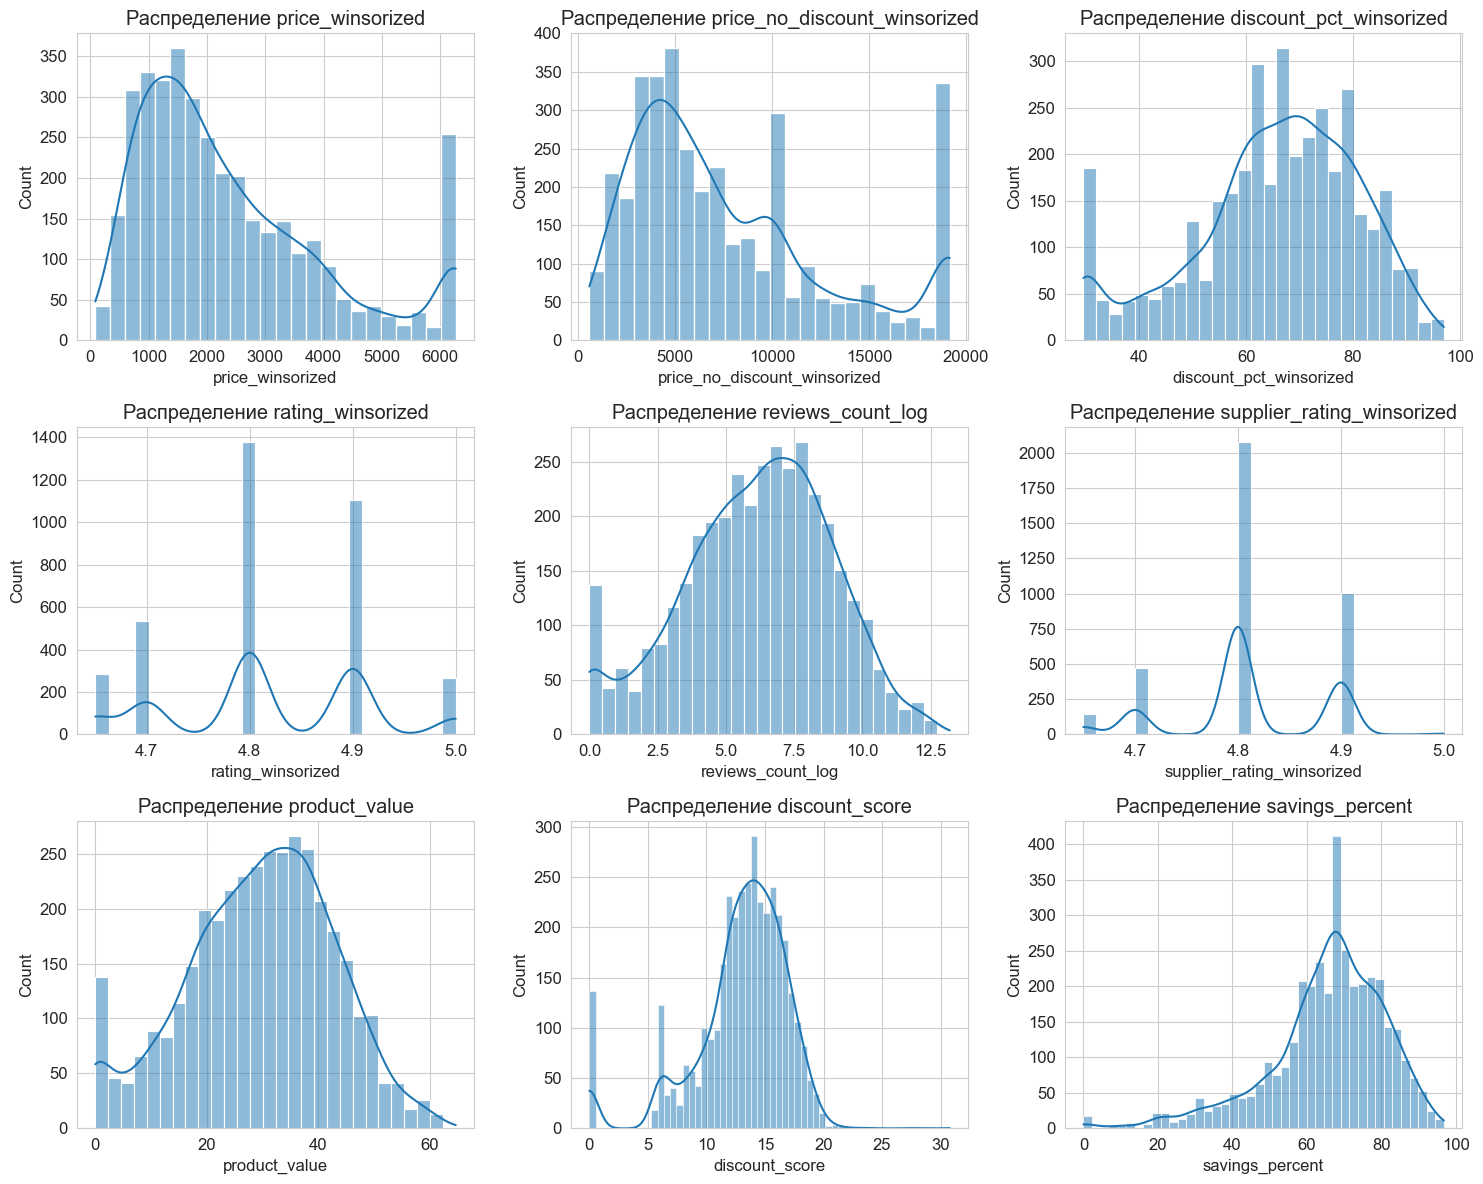

In [22]:
# Визуализация распределений
# Гистограммы всех числовых признаков
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()
for i, col in enumerate(numeric_cols):
    if i < len(axes):
        sns.histplot(df[col], kde=True, ax=axes[i])
        axes[i].set_title(f'Распределение {col}')
plt.tight_layout()
plt.show()

price_winsorized – распределение имеет ярко выраженную правостороннюю асимметрию
(большинство товаров стоят 1000–3000), поэтому для сравнения цен используем непараметрические тесты.

price_no_discount_winsorized – распределение более пологое с умеренной асимметрией 
(основная масса цен 5000–7500), что также требует непараметрических критериев.

discount_pct_winsorized – гистограмма демонстрирует левостороннюю асимметрию
(пик на скидках 60–80%), поэтому для анализа скидок мы применим U-тест Манна–Уитни.

rating_winsorized – распределение смещено в область высоких оценок (4.7–5.0)
и не является нормальным, поэтому для всех тестов с его участием мы используем непараметрические критерии.

reviews_count_log – гистограмма имеет два пика и длинный правый хвост, 
это указывает на отсутствие нормальности, поэтому сравнение отзывов проведет через U-тест.

supplier_rating_winsorized – распределение симметрично с пиком на 4.8–4.9, 
однако для корреляции с рейтингом товара используем коэффициент Спирмена как робастный метод.
    
product_value – распределение имеет правостороннюю асимметрию (большинство значений 
сосредоточены в области низких значений, а правый хвост вытянут до 60), что не соответствует 
нормальному распределению, поэтому для анализа используем непараметрические методы.

discount_score – гистограмма имеет левостороннюю асимметрию и тяжёлые хвосты 
(эксцесс 2.28), следовательно, используем только непараметрические методы.

savings_percent – распределение аналогично discount_score (левосторонний пик), 
поэтому все выводы по экономии строим исключительно на непараметрической статистике.

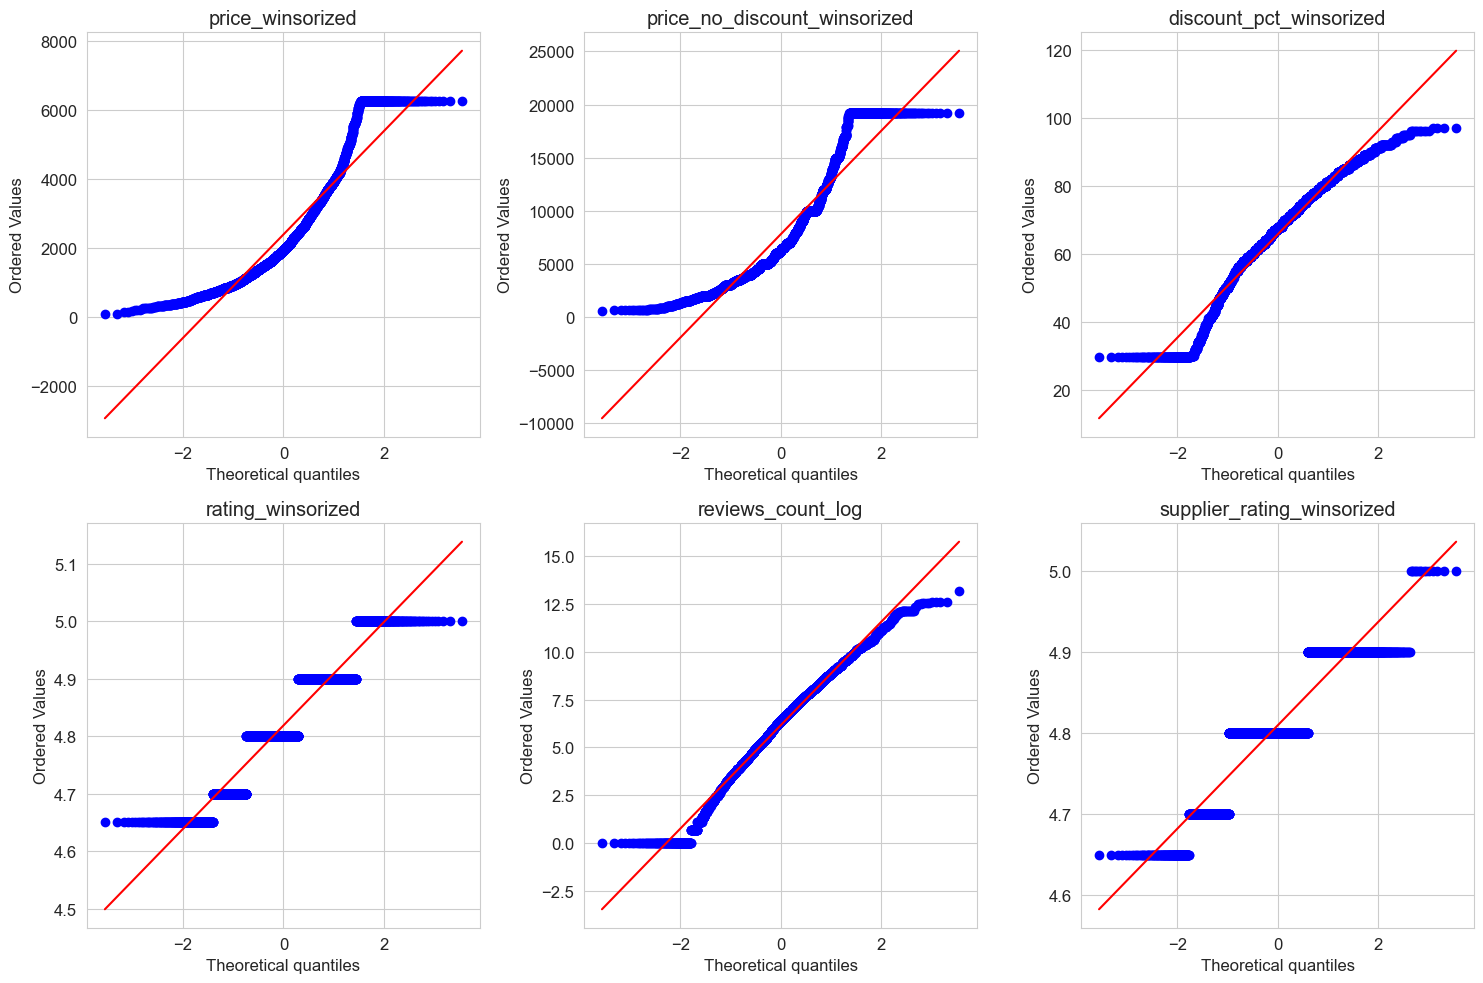

In [85]:
# Квантиль-квантиль графики (Q-Q plots) для проверки нормальности (на примере rating_winsorized)
from scipy import stats

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()
for i, col in enumerate(numeric_cols[:6]):
    stats.probplot(df[col].dropna(), dist="norm", plot=axes[i])
    axes[i].set_title(f'{col}')
plt.tight_layout()
plt.show()

Все построенные графики демонстрируют систематические отклонения от прямой линии:
S-образные изгибы, ступенчатость, скошенные хвосты. Это подтверждает, что ни один
из анализируемых признаков не имеет строго нормального распределения. 
Следовательно, для проверки статистических гипотез мы корректно выбрали непараметрические
критерии, которые не требуют предположения о нормальности.

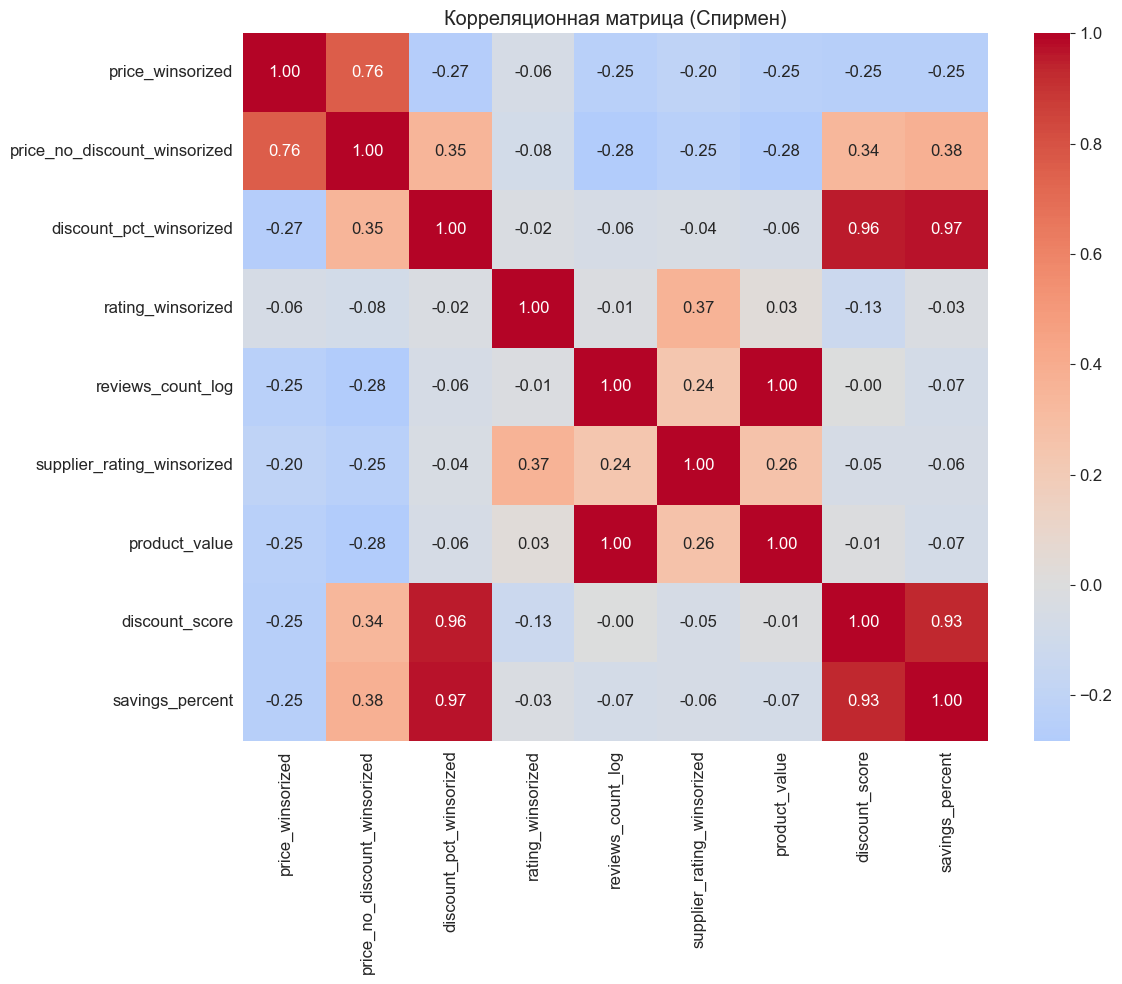

In [32]:
# Корреляции Спирмена
spearman_corr = df[numeric_cols].corr(method='spearman')
plt.figure(figsize=(12, 10))
sns.heatmap(spearman_corr, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Корреляционная матрица (Спирмен)')
plt.tight_layout()
plt.show()

Важные наблюдения:

1. Ожидаемые избыточные связи – discount_pct, savings_percent, discount_score почти совпадают;
reviews_count_log и product_value тоже. Это упрощает выбор признаков для моделей.

2. Гипотеза H6 – корреляция 0.37 между supplier_rating и rating_winsorized статистически значима
(p-value мы проверим отдельно). Это говорит, что рейтинг продавца – полезный предиктор качества товара.

3. Слабая связь скидки и рейтинга – коэффициент -0.02 указывает, что глубина скидки
практически не коррелирует с рейтингом. Это опровергает распространённое мнение, 
что большие скидки = плохое качество. (Но для окончательного вывода нужен тест H1).

In [26]:
# Перед проверкой гипотез оценим распределение ключевых категорий
print("Распределение gender_encoded:")
print(df['gender_encoded'].value_counts().sort_index())

print("\nРаспределение price_tier:")
print(df['price_tier'].value_counts())

print("\nТоп-10 цветов (color_main):")
print(df['color_main'].value_counts().head(10))

Распределение gender_encoded:
gender_encoded
0    2105
1    1371
2      32
3      41
4       9
5     150
Name: count, dtype: int64

Распределение price_tier:
price_tier
Эконом      928
Премиум     927
Бизнес      927
Стандарт    926
Name: count, dtype: int64

Топ-10 цветов (color_main):
color_main
черный         1060
белый           312
серый           253
коричневый      199
синий           195
бежевый         173
голубой         143
темно-синий     135
молочный         72
unknown          71
Name: count, dtype: int64


In [33]:
# Формирование групп данных для гипотез
# H1: две группы по скидке
group_30_50 = df[df['discount_group_h1'] == '30-50%']['rating_winsorized'].dropna()
group_70_plus = df[df['discount_group_h1'] == '>70%']['rating_winsorized'].dropna()
print(f"Размеры групп: 30-50% = {len(group_30_50)}, >70% = {len(group_70_plus)}")

# H2: женский vs мужской (коды 0 и 1)
female_rating = df[df['gender_encoded'] == 0]['rating_winsorized'].dropna()
male_rating = df[df['gender_encoded'] == 1]['rating_winsorized'].dropna()
print(f"Женщины: {len(female_rating)}, Мужчины: {len(male_rating)}")

# H3: группы стран
premium_countries = df[df['country_group_h3'] == 'Премиум']['price_winsorized'].dropna()
russia = df[df['country_group_h3'] == 'Россия']['price_winsorized'].dropna()
china = df[df['country_group_h3'] == 'Китай']['price_winsorized'].dropna()
print(f"Премиум: {len(premium_countries)}, Россия: {len(russia)}, Китай: {len(china)}")

# H4: премиум бренды vs остальные
premium_discount = df[df['is_premium_brand'] == 1]['discount_pct_winsorized'].dropna()
non_premium_discount = df[df['is_premium_brand'] == 0]['discount_pct_winsorized'].dropna()
print(f"Премиум брендов: {len(premium_discount)}, Остальных: {len(non_premium_discount)}")

# H5: платья вечерние vs юбки
dress_reviews = df[df['is_evening_dress'] == 1]['reviews_count_log'].dropna()
skirt_reviews = df[df['is_skirt'] == 1]['reviews_count_log'].dropna()
print(f"Платья вечерние: {len(dress_reviews)}, Юбки: {len(skirt_reviews)}")

Размеры групп: 30-50% = 423, >70% = 1508
Женщины: 2027, Мужчины: 1326
Премиум: 192, Россия: 1306, Китай: 793
Премиум брендов: 121, Остальных: 3587
Платья вечерние: 84, Юбки: 247


In [42]:
# Проверка гипотез
from scipy.stats import mannwhitneyu, kruskal, spearmanr

# H1:
# Нулевая гипотеза (H0): Средний рейтинг товаров со скидкой 30–50% не выше, чем у товаров со скидкой >70%
# Альтернативная (H1): Средний рейтинг в группе 30–50% выше, чем в группе > 70%
print("\nH1: Влияние скидки на рейтинг")
print(f"  Группа 30-50%: n={len(group_30_50)}, средний рейтинг={group_30_50.mean():.3f}")
print(f"  Группа > 70%: n={len(group_70_plus)}, средний рейтинг={group_70_plus.mean():.3f}")
stat, p_h1 = mannwhitneyu(group_30_50, group_70_plus, alternative='greater')
print(f"  Mann-Whitney U: {stat:.2f}, p-value (односторонний): {p_h1:.6f}")
if p_h1 < 0.05:
    print("  ВЫВОД: Отвергаем H0: рейтинг при скидке 30-50% значимо выше")
else:
    print("  ВЫВОД: H0 не отвергается: разница в рейтинге не значима")


H1: Влияние скидки на рейтинг
  Группа 30-50%: n=423, средний рейтинг=4.814
  Группа > 70%: n=1508, средний рейтинг=4.816
  Mann-Whitney U: 316254.00, p-value (односторонний): 0.609615
  ВЫВОД: H0 не отвергается: разница в рейтинге не значима


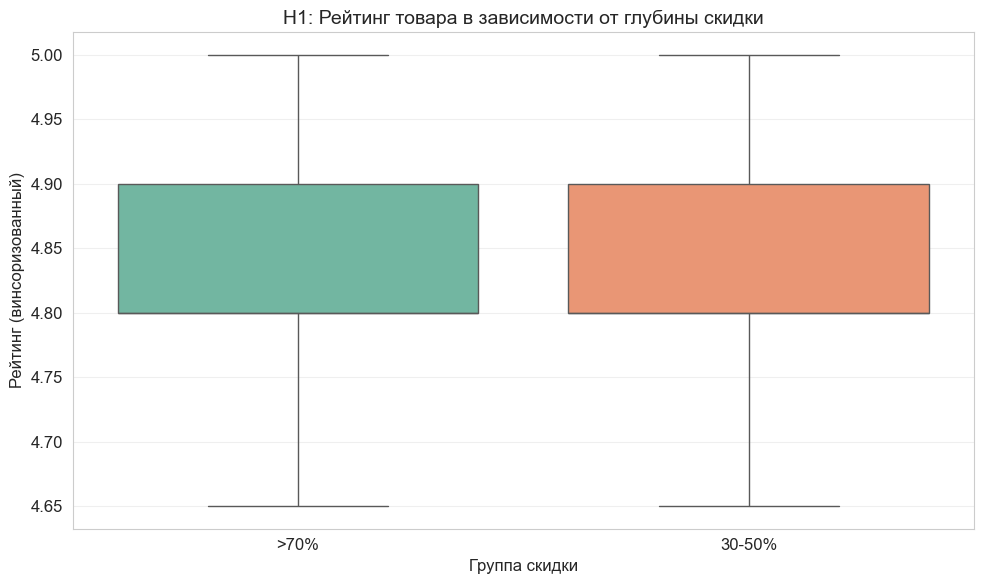

In [58]:
# Визуализация для H1
import matplotlib.pyplot as plt
import seaborn as sns

df_h1 = df[df['discount_group_h1'].isin(['30-50%', '>70%'])].copy()
plt.figure()
sns.boxplot(data=df_h1, x='discount_group_h1', y='rating_winsorized', palette='Set2')
plt.title('H1: Рейтинг товара в зависимости от глубины скидки', fontsize=14)
plt.xlabel('Группа скидки')
plt.ylabel('Рейтинг (винсоризованный)')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

H1. Влияние скидки на рейтинг

Результат: p-value = 0.61 (не значимо, α=0.05)

Вывод: Глубина скидки не влияет на рейтинг товара. 
Товары со скидкой 30–50% и товары со скидкой >70% имеют практически одинаковый средний рейтинг (4.81–4.82).

Практический смысл: Потребители не снижают оценку за большие скидки. 
Маркетплейсы могут проводить глубокие распродажи без риска ухудшения восприятия качества.

In [64]:
# H2: Женская vs Мужская одежда (рейтинг)
print("\nH2: Гендерные различия в рейтинге")
print(f"  Женская: n={len(female_rating)}, средний рейтинг={female_rating.mean():.3f}")
print(f"  Мужская: n={len(male_rating)}, средний рейтинг={male_rating.mean():.3f}")
stat, p_h2 = mannwhitneyu(female_rating, male_rating, alternative='greater')
print(f"  Mann-Whitney U: {stat:.2f}, p-value (односторонний): {p_h2:.6f}")
if p_h2 < 0.05:
    print("  ВЫВОД: Отвергаем H0: женская одежда имеет более высокий рейтинг")
else:
    print("  ВЫВОД: H0 не отвергается: рейтинг женской одежды не выше мужской")


H2: Гендерные различия в рейтинге
  Женская: n=2027, средний рейтинг=4.813
  Мужская: n=1326, средний рейтинг=4.826
  Mann-Whitney U: 1248447.50, p-value (односторонний): 0.999872
  ВЫВОД: H0 не отвергается: рейтинг женской одежды не выше мужской


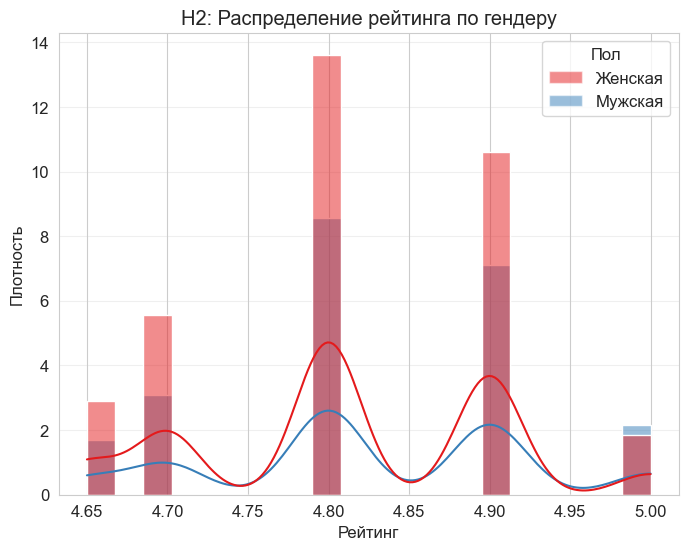

In [69]:
# Визуализация Н2
plt.figure(figsize=(8,6))
sns.histplot(data=df_h2, x='rating_winsorized', hue='gender_label',
             kde=True, stat='density', alpha=0.5, palette='Set1', bins=20)
plt.title('H2: Распределение рейтинга по гендеру')
plt.xlabel('Рейтинг')
plt.ylabel('Плотность')
legend_elements = [Patch(facecolor='#e41a1c', alpha=0.5, label='Женская'),
                   Patch(facecolor='#377eb8', alpha=0.5, label='Мужская')]
plt.legend(handles=legend_elements, title='Пол')
plt.grid(axis='y', alpha=0.3)
plt.show()

H2. Гендерные различия в рейтинге

Результат: p-value = 0.9999 (не значимо)

Вывод: Рейтинг женской одежды не выше рейтинга мужской.
Средние значения почти одинаковы (4.813 vs 4.826), распределения идентичны.

Практический смысл: Требования к качеству и удовлетворённость не зависят от гендера.
Бренды могут не делать поправку на пол при оценке потребительских ожиданий.

In [70]:
# H3: Разница в цене между странами (Россия, Китай, Премиум)
print("\nH3: Сравнение цен по группам стран")
print(f"  Россия: n={len(russia)}, средняя цена={russia.mean():.0f}")
print(f"  Китай: n={len(china)}, средняя цена={china.mean():.0f}")
print(f"  Премиум: n={len(premium_countries)}, средняя цена={premium_countries.mean():.0f}")
stat, p_h3 = kruskal(russia, china, premium_countries)
print(f"  Kruskal-Wallis H: {stat:.2f}, p-value: {p_h3:.6f}")
if p_h3 < 0.05:
    print("  ВЫВОД: Отвергаем H0: есть значимые различия в ценах между странами")
    # Попарные сравнения с поправкой Бонферрони
    from scipy.stats import mannwhitneyu
    alpha_adj = 0.05 / 3
    p_ru_cn = mannwhitneyu(russia, china, alternative='two-sided').pvalue
    p_ru_pr = mannwhitneyu(russia, premium_countries, alternative='two-sided').pvalue
    p_cn_pr = mannwhitneyu(china, premium_countries, alternative='two-sided').pvalue
    print(f"  Попарно: Россия vs Китай p={p_ru_cn:.4f} {'значимо' if p_ru_cn<alpha_adj else 'не значимо'}")
    print(f"           Россия vs Премиум p={p_ru_pr:.4f} {'значимо' if p_ru_pr<alpha_adj else 'не значимо'}")
    print(f"           Китай vs Премиум p={p_cn_pr:.4f} {'значимо' if p_cn_pr<alpha_adj else 'не значимо'}")
else:
    print("  ВЫВОД: H0 не отвергается: значимых различий в ценах нет")


H3: Сравнение цен по группам стран
  Россия: n=1306, средняя цена=2336
  Китай: n=793, средняя цена=2475
  Премиум: n=192, средняя цена=3348
  Kruskal-Wallis H: 47.56, p-value: 0.000000
  ВЫВОД: Отвергаем H0: есть значимые различия в ценах между странами
  Попарно: Россия vs Китай p=0.0912 не значимо
           Россия vs Премиум p=0.0000 значимо
           Китай vs Премиум p=0.0000 значимо


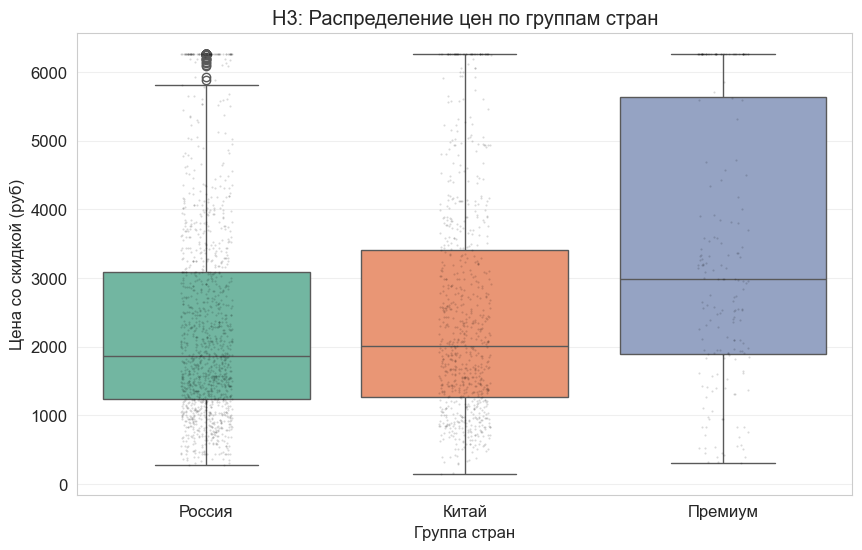

In [73]:
# Визуализация Н3
plt.figure(figsize=(10,6))
df_h3 = df[df['country_group_h3'].isin(['Россия', 'Китай', 'Премиум'])].copy()
# Фиксируем порядок
df_h3['country_group_h3'] = pd.Categorical(df_h3['country_group_h3'], 
                                           categories=['Россия', 'Китай', 'Премиум'], 
                                           ordered=True)
sns.boxplot(data=df_h3, x='country_group_h3', y='price_winsorized', palette='Set2')
sns.stripplot(data=df_h3, x='country_group_h3', y='price_winsorized', 
              color='black', alpha=0.15, size=1.5, jitter=True)
plt.title('H3: Распределение цен по группам стран')
plt.xlabel('Группа стран')
plt.ylabel('Цена со скидкой (руб)')
plt.grid(axis='y', alpha=0.3)
plt.show()

H3. Различия в цене между группами стран

Результат: Kruskal-Wallis p < 0.001 (значимо)

Попарно: Россия vs Китай – не значимо (p=0.091);
         Россия vs Премиум – значимо (p<0.001);
         Китай vs Премиум – значимо (p<0.001).
             
Вывод: Цены на товары из премиум-группы значимо выше, чем из России и Китая. 
Между Россией и Китаем статистически значимой разницы в ценах нет.

Практический смысл: Производство в «премиальных» странах ассоциируется с более высокой ценой,
что может быть использовано в ценообразовании.

In [74]:
# H4: Премиум-бренды vs остальные (скидка)
print("\nH4: Сравнение скидок премиум-брендов и масс-маркета")
print(f"  Премиум: n={len(premium_discount)}, средняя скидка={premium_discount.mean():.1f}%")
print(f"  Остальные: n={len(non_premium_discount)}, средняя скидка={non_premium_discount.mean():.1f}%")
stat, p_h4 = mannwhitneyu(premium_discount, non_premium_discount, alternative='less')
print(f"  Mann-Whitney U: {stat:.2f}, p-value (односторонний, премиум < остальные): {p_h4:.6f}")
if p_h4 < 0.05:
    print("  ВЫВОД: Отвергаем H0: премиум-бренды имеют значимо меньшую скидку")
else:
    print("  ВЫВОД: H0 не отвергается: скидки премиум-брендов не ниже масс-маркета")


H4: Сравнение скидок премиум-брендов и масс-маркета
  Премиум: n=121, средняя скидка=55.4%
  Остальные: n=3587, средняя скидка=66.0%
  Mann-Whitney U: 138119.00, p-value (односторонний, премиум < остальные): 0.000000
  ВЫВОД: Отвергаем H0: премиум-бренды имеют значимо меньшую скидку


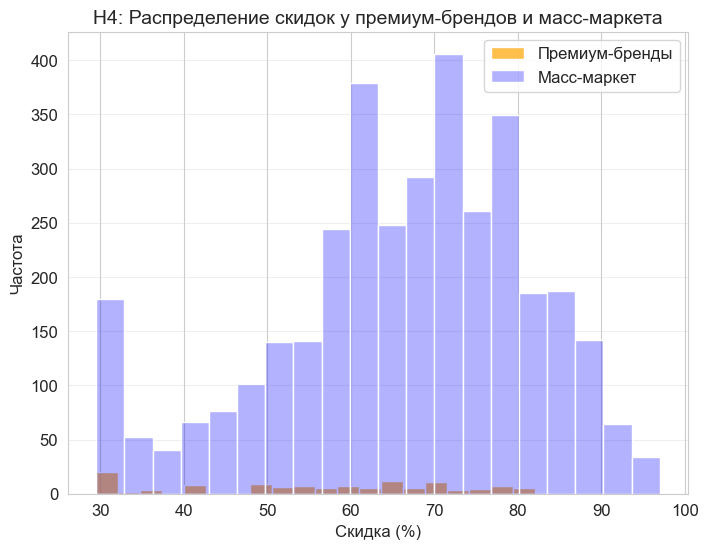

In [77]:
# Визуализация Н4
plt.figure(figsize=(8,6))
sns.histplot(premium_discount, bins=20, alpha=0.7, label='Премиум-бренды', color='orange')
sns.histplot(non_premium_discount, bins=20, alpha=0.3, label='Масс-маркет', color='blue')
plt.title('H4: Распределение скидок у премиум-брендов и масс-маркета', fontsize=14)
plt.xlabel('Скидка (%)')
plt.ylabel('Частота')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()

H4. Скидки премиум-брендов и масс-маркета

Результат: p < 0.001 (значимо)

Средняя скидка: премиум-бренды – 55.4%, масс-маркет – 66.0%.
    
Вывод: Премиум-бренды дают значимо меньшие скидки, чем масс-маркет.

Практический смысл: Люксовые бренды реже участвуют в глубоких распродажах,
сохраняя ценовой престиж. Масс-маркет использует скидки как основной инструмент 
привлечения покупателей.

In [54]:
# H5: Платья вечерние vs юбки (количество отзывов)
print("\nH5: Сравнение количества отзывов (логарифм) у платьев вечерних и юбок")
print(f"  Платья вечерние: n={len(dress_reviews)}, средний log(отзывы)={dress_reviews.mean():.2f}")
print(f"  Юбки: n={len(skirt_reviews)}, средний log(отзывы)={skirt_reviews.mean():.2f}")
stat, p_h5 = mannwhitneyu(dress_reviews, skirt_reviews, alternative='greater')
print(f"  Mann-Whitney U: {stat:.2f}, p-value (односторонний): {p_h5:.6f}")
if p_h5 < 0.05:
    print("  ВЫВОД: Отвергаем H0: у вечерних платьев значимо больше отзывов, чем у юбок")
else:
    print("  ВЫВОД: H0 не отвергается: разница в отзывах не значима")


H5: Сравнение количества отзывов (логарифм) у платьев вечерних и юбок
  Платья вечерние: n=84, средний log(отзывы)=6.33
  Юбки: n=247, средний log(отзывы)=6.25
  Mann-Whitney U: 10336.50, p-value (односторонний): 0.520002
  ВЫВОД: H0 не отвергается: разница в отзывах не значима


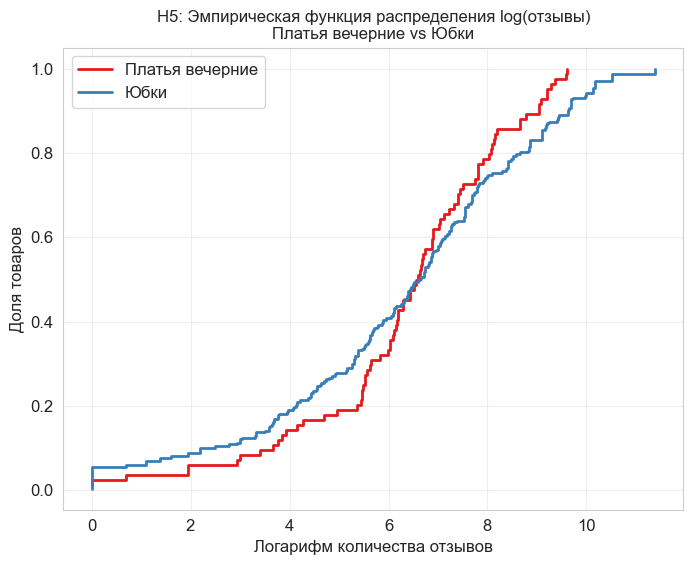

In [79]:
# Визуализация Н5
df_h5 = df[(df['is_evening_dress']==1) | (df['is_skirt']==1)].copy()
df_h5['category'] = df_h5['is_evening_dress'].map({1:'Платья вечерние',0:'Юбки'})

plt.figure(figsize=(8,6))
for cat, color in zip(['Платья вечерние', 'Юбки'], ['#e41a1c', '#377eb8']):
    data = df_h5[df_h5['category'] == cat]['reviews_count_log'].dropna()
    x = np.sort(data)
    y = np.arange(1, len(x)+1) / len(x)
    plt.step(x, y, where='post', label=cat, color=color, linewidth=2)

plt.title('H5: Эмпирическая функция распределения log(отзывы)\nПлатья вечерние vs Юбки', fontsize=12)
plt.xlabel('Логарифм количества отзывов')
plt.ylabel('Доля товаров')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

H5. Количество отзывов: вечерние платья и юбки

Результат: p-value = 0.52 (не значимо)

Средний log(отзывы): платья – 6.33, юбки – 6.25.

Вывод: Количество отзывов (в логарифмической шкале) не различается между вечерними платьями и юбками.

Практический смысл: Обе категории одинаково активно обсуждаются покупателями. 
Нет оснований ожидать, что вечерние платья вызовут больше откликов.

In [80]:
# H6: Корреляция между рейтингом товара и рейтингом продавца
print("\nH6: Корреляция rating_winsorized и supplier_rating_winsorized")

corr_data = df[['supplier_rating_winsorized', 'rating_winsorized']].dropna()
supplier = corr_data['supplier_rating_winsorized']
rating = corr_data['rating_winsorized']
corr_coef, p_h6_two = spearmanr(supplier, rating)

if corr_coef > 0:
    p_h6 = p_h6_two / 2
else:
    p_h6 = 1 - p_h6_two / 2
print(f"  Коэффициент Спирмена: {corr_coef:.3f}, p-value (односторонний): {p_h6:.6f}")
if p_h6 < 0.05:
    print("  ВЫВОД: Отвергаем H0: есть значимая положительная корреляция")
else:
    print("  ВЫВОД: H0 не отвергается: значимой положительной корреляции нет")


H6: Корреляция rating_winsorized и supplier_rating_winsorized
  Коэффициент Спирмена: 0.368, p-value (односторонний): 0.000000
  ВЫВОД: Отвергаем H0: есть значимая положительная корреляция


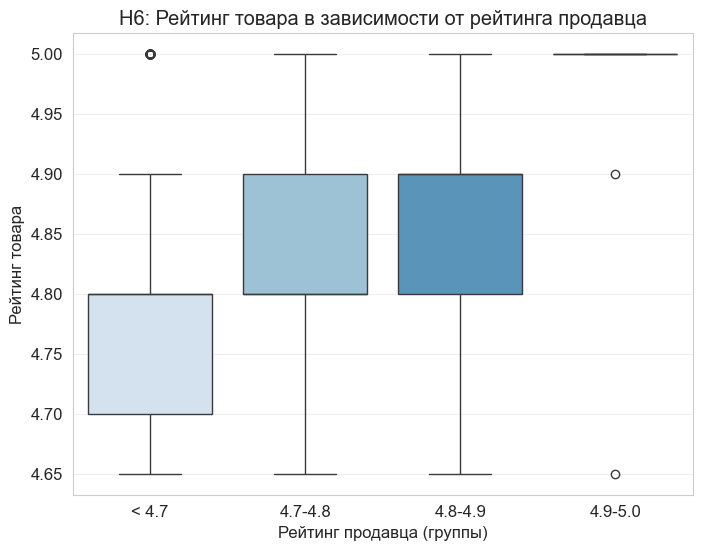

In [82]:
# Визуализация Н6
df_h6 = df[['supplier_rating_winsorized', 'rating_winsorized']].dropna().copy()
df_h6['supplier_group'] = pd.cut(df_h6['supplier_rating_winsorized'], 
                                 bins=[0, 4.7, 4.8, 4.9, 5.0], 
                                 labels=['< 4.7', '4.7-4.8', '4.8-4.9', '4.9-5.0'],
                                 include_lowest=True)

plt.figure(figsize=(8,6))
sns.boxplot(data=df_h6, x='supplier_group', y='rating_winsorized', palette='Blues')
plt.title('H6: Рейтинг товара в зависимости от рейтинга продавца')
plt.xlabel('Рейтинг продавца (группы)')
plt.ylabel('Рейтинг товара')
plt.grid(axis='y', alpha=0.3)
plt.show()

H6. Корреляция рейтинга товара и рейтинга продавца

Результат: ρ Спирмена = 0.368, p < 0.001 (значимая положительная корреляция).

Вывод: Существует умеренная положительная связь между рейтингом продавца и рейтингом товара.
Чем выше рейтинг продавца, тем выше, как правило, рейтинг товара.

Практический смысл: Выбор продавца с высоким рейтингом повышает вероятность получения качественного
товара. Это важный сигнал для покупателей и для самой платформы при ранжировании продавцов.

### Общие выводы анализу

Было проверено 6 статистических гипотез. Все тесты проводились с использованием непараметрических методов (Манна–Уитни, Краскела–Уоллиса, Спирмена) ввиду ненормальности распределений исследуемых признаков.


### H1. Влияние скидки на рейтинг товара

Суть гипотезы: 
Товары со скидкой 30–50% имеют более высокий рейтинг, чем товары со скидкой >70% (потребители якобы не доверяют слишком большим скидкам).

Результат:

- Средний рейтинг в группе 30–50%: 4.814

- Средний рейтинг в группе >70%: 4.816

- U-тест Манна–Уитни: p-value = 0.61 (односторонний, a = 0.05 - не значимо).

**Вывод:**
Глубина скидки не влияет на рейтинг товара. Товары с очень глубокими скидками (>70%) оцениваются покупателями так же хорошо, как и товары с умеренными скидками (30–50%).

- Продавцы могут проводить глубокие распродажи без риска ухудшения восприятия качества.
- Маркетплейс может не штрафовать (в рейтинговых алгоритмах) товары с высокими скидками.
- Это опровергает распространённый миф: «большая скидка = плохой товар».



### H2. Гендерные различия в рейтинге

Суть гипотезы: 
Женская одежда имеет более высокий рейтинг, чем мужская (предположительно из-за более высоких требований или другой аудитории).

Результат:

- Женская одежда: n = 2027, средний рейтинг = 4.813  

- Мужская одежда: n = 1326, средний рейтинг = 4.826  

- U-тест Манна–Уитни: p-value = 0.9999 - не значимо (разница в средних — всего 0.013).

**Вывод:**  
Рейтинг женской одежды не выше и не ниже рейтинга мужской. Распределения оценок практически идентичны.
  
- Требования к качеству и удовлетворённость не зависят от пола покупателя.
- Бренды могут не делать поправку на пол при оценке потребительских ожиданий.
- Это также означает, что текстовые и когнитивные приёмы можно унифицировать для обоих полов.


### H3. Различия в цене между группами стран

Суть гипотезы:
Цены на товары из России, Китая и «премиум-стран» (Италия, Германия и др.) различаются.

Результат:

- Россия: n = 1306, средняя цена = 2336 руб.  

- Китай: n = 793, средняя цена = 2475 руб. 

- Премиум-страны: n = 192, средняя цена = 3348 руб.  

- Критерий Краскела–Уоллиса: p-value = 0.000000 - значимо.

Попарно (с поправкой Бонферрони, a = 0.0167):

- Россия vs Китай: p = 0.091 - не значимо 

- Россия vs Премиум: p = 0.0000 - значимо 

- Китай vs Премиум: p = 0.0000 - значимо

**Вывод:**  
- Между Россией и Китаем нет статистически значимой разницы в ценах.
- Обе страны значимо дешевле «премиум-группы».

- Покупатели готовы платить больше за товары из стран с «премиум-репутацией» (Италия, Германия и др.).
- Это можно использовать в ценообразовании и маркировке товара («Made in Italy» и т.д.).
- Россия и Китай находятся в одной ценовой нише — конкуренция между ними идёт не по цене, а по другим факторам (дизайн, качество, бренд).



### H4. Скидки у премиум-брендов vs масс-маркет

Суть гипотезы: 
Премиум-бренды дают меньшие скидки, чем масс-маркет (сохраняют ценовой престиж).

Результат:

- Премиум-бренды (n = 121): средняя скидка = 55.4%

- Масс-маркет (n = 3587): средняя скидка = 66.0%

- U-тест Манна–Уитни: p-value (односторонний) = 0.000000 - значимо.

**Вывод:**  
Премиум-бренды действительно дают значимо меньшие скидки, чем масс-маркет. Разница в средней скидке — более 10 процентных пунктов.

- Люксовые бренды реже участвуют в глубоких распродажах, сохраняя ценовой престиж.
- Масс-маркет использует скидки как основной инструмент привлечения покупателей.
- Для нового бренда: если вы хотите позиционироваться как премиум — не стоит гнаться за глубокими скидками. Это не ухудшит рейтинг (см. H1), но сохранит маржинальность.



### H5. Количество отзывов: вечерние платья vs юбки

Суть гипотезы:
У вечерних платьев больше отзывов, чем у юбок (как у более «эмоциональных» и редко покупаемых товаров).

Результат:

- Вечерние платья: n = 84, средний log(отзывы) = 6.33  

- Юбки: n = 247, средний log(отзывы) = 6.25 

- U-тест Манна–Уитни: p-value (односторонний) = 0.520 - не значимо.

**Вывод:**  
Количество отзывов (в логарифмической шкале) не различается между вечерними платьями и юбками. Обе категории одинаково активно обсуждаются покупателями.

- Нет оснований ожидать, что вечерние платья вызовут больше откликов (отзывов) автоматически.
- Для стимулирования отзывов в любой категории нужны дополнительные инструменты (бонусы за отзыв, напоминания и т.д.).
- Это также говорит о том, что «эмоциональная вовлечённость» в этих категориях примерно одинакова.



### H6. Корреляция рейтинга товара и рейтинга продавца

Суть гипотезы: 
Рейтинг продавца положительно связан с рейтингом товара (покупатели доверяют проверенным продавцам).

Результат:

- Коэффициент корреляции Спирмена: р = 0.368  

- p-value (односторонний) = 0.000000 - значимо.

**Вывод:**  
Существует умеренная положительная корреляция (по шкале Чеддока — «заметная») между рейтингом продавца и рейтингом товара. Связь не сильная (0.37, а не 0.7–0.9), но статистически значимая и устойчивая.
 
- Выбор продавца с высоким рейтингом повышает вероятность получить качественный товар.
- Это важный сигнал для покупателей при выборе между несколькими предложениями.
- Для маркетплейса: рейтинг продавца должен учитываться в ранжировании (как минимум как один из факторов), так как он значимо коррелирует с итоговым качеством товара.


### Если делать выводы, то что это всё значит для продавца?


**Скидки:** Масс-маркет может смело делать скидки хоть до 70% — рейтинг от этого не падает. Покупатели не считают большие скидки признаком плохого качества. Премиум-бренды тоже могут не гнаться за глубокими распродажами: их покупатели и так готовы платить больше, а маленькие скидки рейтингу не вредят.

**Страны производства:** Товары из Италии, Германии и других «премиум-стран» продаются дороже российских и китайских. При этом Россия и Китай по цене не различаются. Страну стоит указывать и использовать как аргумент для более высокой цены.

**Доверие:** Рейтинг продавца и рейтинг товара связаны. Чем выше рейтинг продавца, тем выше, как правило, рейтинг его товаров. Покупатели переносят недоверие к продавцу на товар. Работать над рейтингом — не просто престиж, а прямой способ повысить оценки.

**Гендер:** Мужчины и женщины оценивают товары одинаково. Не нужно делить аудиторию и подстраивать стратегии под пол.


Главный вопрос проекта звучал так: на что нужно обращать внимание, чтобы товар был востребован на WildBerries? Ценовая политика и позиционирование — это действительно важно. Премиум-позиционирование, выраженное либо через бренд, либо через страну производства, позволяет продавцу держать более высокую цену и давать меньшие скидки, и это совершенно не вредит рейтингу товара. Масс-маркет, в свою очередь, может и даже должен использовать скидки как основной инструмент привлечения покупателей.

Также доверие к продавцу — критический фактор.
Рейтинг продавца и рейтинг товара связаны. Покупатели не отделяют одно от другого: плохой продавец автоматически подозревается в том, что и товар у него плохой, даже если это не так. Следовательно, вложения в репутацию продавца окупаются напрямую через повышение оценок каждого товара.


Гендерная нейтральность означает, что текстовые и когнитивные приёмы не нужно адаптировать под пол. Универсальные паттерны — выгода, доверие, срочность, социальное доказательство — работают одинаково хорошо для мужчин и женщин.
Скидка как инструмент оказалась совершенно безопасной с точки зрения рейтинга. Это значит, что в текстах и описаниях можно смело использовать приёмы, создающие ощущение выгоды: слова «скидка», «распродажа», «выгода до X%», «успейте», «ограниченное предложение». Они не снижают оценку товара и могут повышать конверсию.

### Итог по числовым данным:
продавцу на WildBerries стоит сосредоточиться на двух вещах: на своём рейтинге (потому что он напрямую влияет на оценки товаров) и на ценовой стратегии (масс-маркету можно давать глубокие скидки без страха, премиум-сегменту — держать цену). Всё остальное — гендер, категория товара — не имеет статистически значимого эффекта.